# Student Performance Prediction

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

np.random.seed(42)
plt.style.use("ggplot")

## Data

Preview of the dataset:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]

Dataset shape: (649, 33)


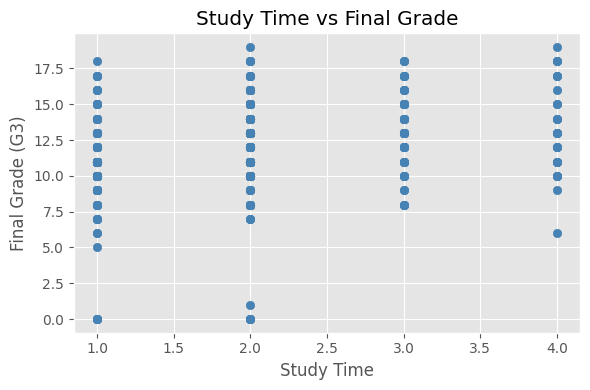

In [22]:
student_data = pd.read_csv("student-por.csv")

print("Preview of the dataset:")
print(student_data.head())
print("\nDataset shape:", student_data.shape)

plt.figure(figsize=(6, 4))
plt.scatter(student_data["studytime"], student_data["G3"], color="steelblue")
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()

## Model

In [23]:
features = student_data[["studytime", "failures", "absences", "Medu", "Fedu", "goout", "Dalc", "Walc", "health"]]
target = student_data["G3"]

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("regressor", Ridge(alpha=1.0)),
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    model,
    features,
    target,
    cv=cv,
    scoring={"mae": "neg_mean_absolute_error", "r2": "r2"},
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Cross-validated performance:")
print(f"Mean MAE: {-cv_results['test_mae'].mean():.2f}")
print(f"Mean R-squared: {cv_results['test_r2'].mean():.2f}")
print()
print("Holdout performance:")
print(f"MAE: {mae:.2f}")
print(f"R-squared: {r2:.2f}")

Cross-validated performance:
Mean MAE: 2.12
Mean R-squared: 0.19

Holdout performance:
MAE: 2.33
R-squared: 0.13


## Output

In [ ]:
print("\nFinal dataset used in the project:")
print(student_data.head())

Predicted final grade for the new student:
13.81

Final dataset used in the project:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]


In [ ]:
new_student = pd.DataFrame({
    "studytime": [3],
    "failures": [0],
    "absences": [4],
    "Medu": [4],
    "Fedu": [4],
    "goout": [2],
    "Dalc": [1],
    "Walc": [1],
    "health": [4],
})

predicted_score = model.predict(new_student)[0]
print("Predicted final grade for the new student:")
print(f"{predicted_score:.2f}")